In [1]:
!pip install statsmodels pandas matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = [12,5]

In [3]:
milk = pd.read_csv(
    "https://raw.githubusercontent.com/PacktPublishing/Time-Series-Analysis-with-Python-Cookbook/main/datasets/Ch10/milk_production.csv",
    index_col='month',
    parse_dates=True
)

milk.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


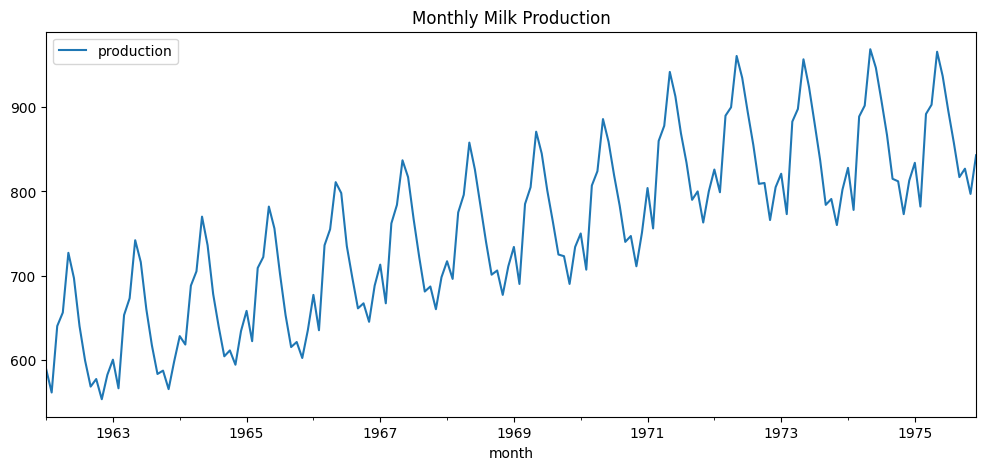

In [4]:
milk.plot(title="Monthly Milk Production")
plt.show()

In [5]:
def split_data(data, test_split):
    l = len(data)
    t_idx = round(l*(1-test_split))
    train, test = data[:t_idx], data[t_idx:]
    print(f"train: {len(train)}, test: {len(test)}")
    return train, test

milk_train, milk_test = split_data(milk, 0.15)

train: 143, test: 25


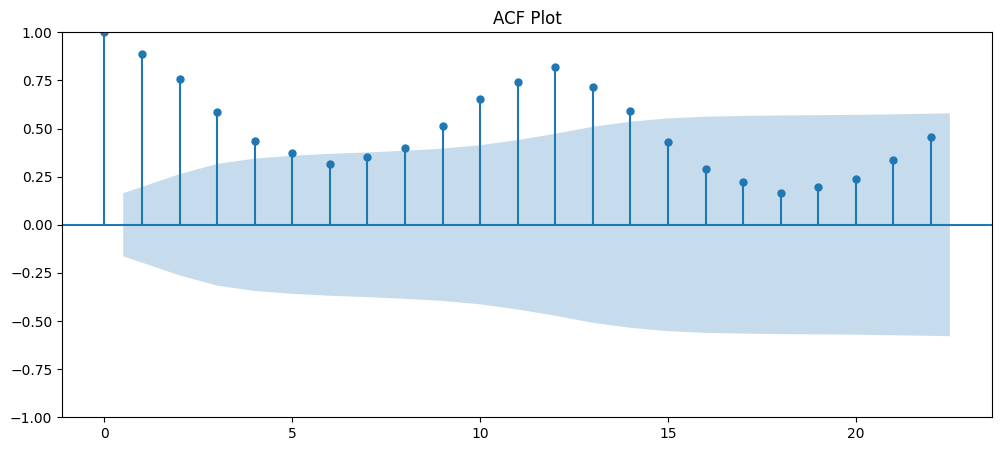

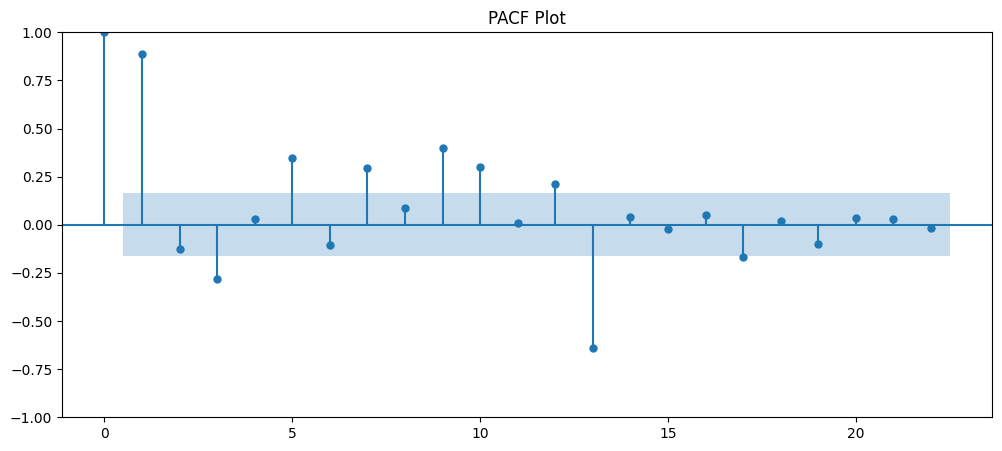

In [6]:
plot_acf(milk_train)
plt.title("ACF Plot")
plt.show()

plot_pacf(milk_train)
plt.title("PACF Plot")
plt.show()

In [7]:
model = ExponentialSmoothing(
    milk_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

forecast = model.forecast(len(milk_test))

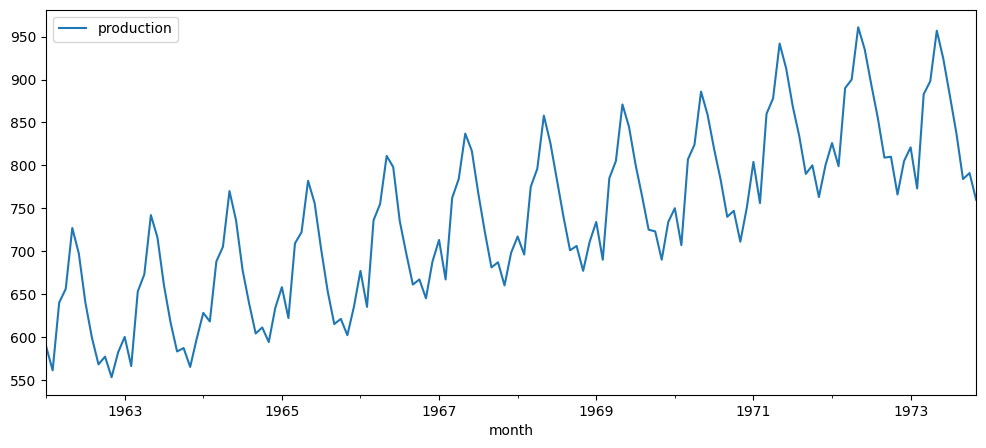

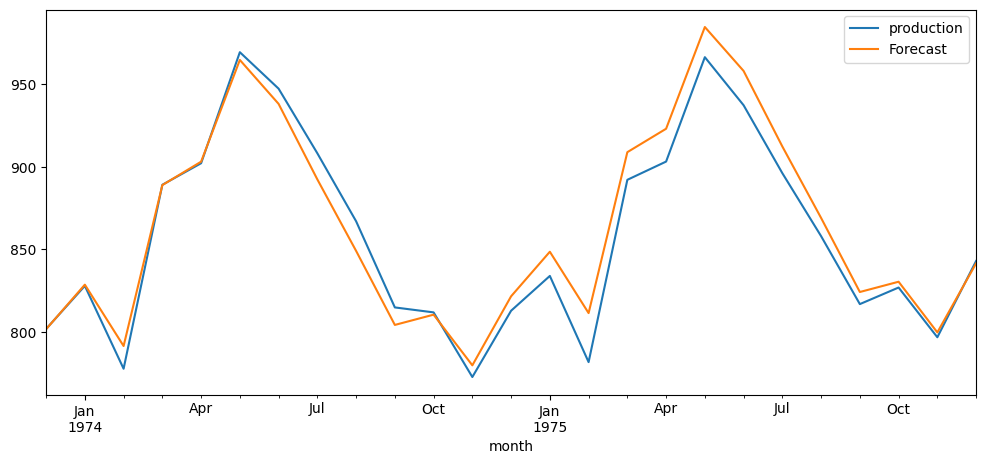

In [8]:
milk_train.plot(label="Train")
milk_test.plot(label="Test")
forecast.plot(label="Forecast")
plt.legend()
plt.show()